Imports

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import NegativeBinomial, Poisson


In [22]:
# Read the CSV file into a DataFrame
df = pd.read_csv("AUdata.csv")

# Display the first few rows
df.head()

,ID,AADT,Length,NumLane,LWIDTH,FuncDum,Shoulder,SHType,SHWidth,SHMark,...,ROUGH,RUTT,Rain,Sun,THUNDER,WIND,Fatal,Major,Minor,Crash
0,1,15692.50,332,1,3.0,0,0,0,2.1,0,...,0,0,"26,667","2,667",30,0,0,3,0,3
1,2,15692.50,333,1,3.0,0,0,0,2.1,0,...,0,0,"33,333","2,625",30,0,0,3,0,3
2,3,12827.00,200,1,3.2,0,0,0,2.1,0,...,0,0,37.5,"2,625",25,0,0,0,0,0
3,4,12986.25,1064,2,3.0,0,0,0,2.1,0,...,60,2.2,30,3,25,0,0,7,1,8
4,5,28713.75,755,3,4.2,0,0,0,3.0,0,...,85.5,6.25,60,3,25,0,0,23,6,29


# Data Exploration (Histograms & Correlation Matrix)

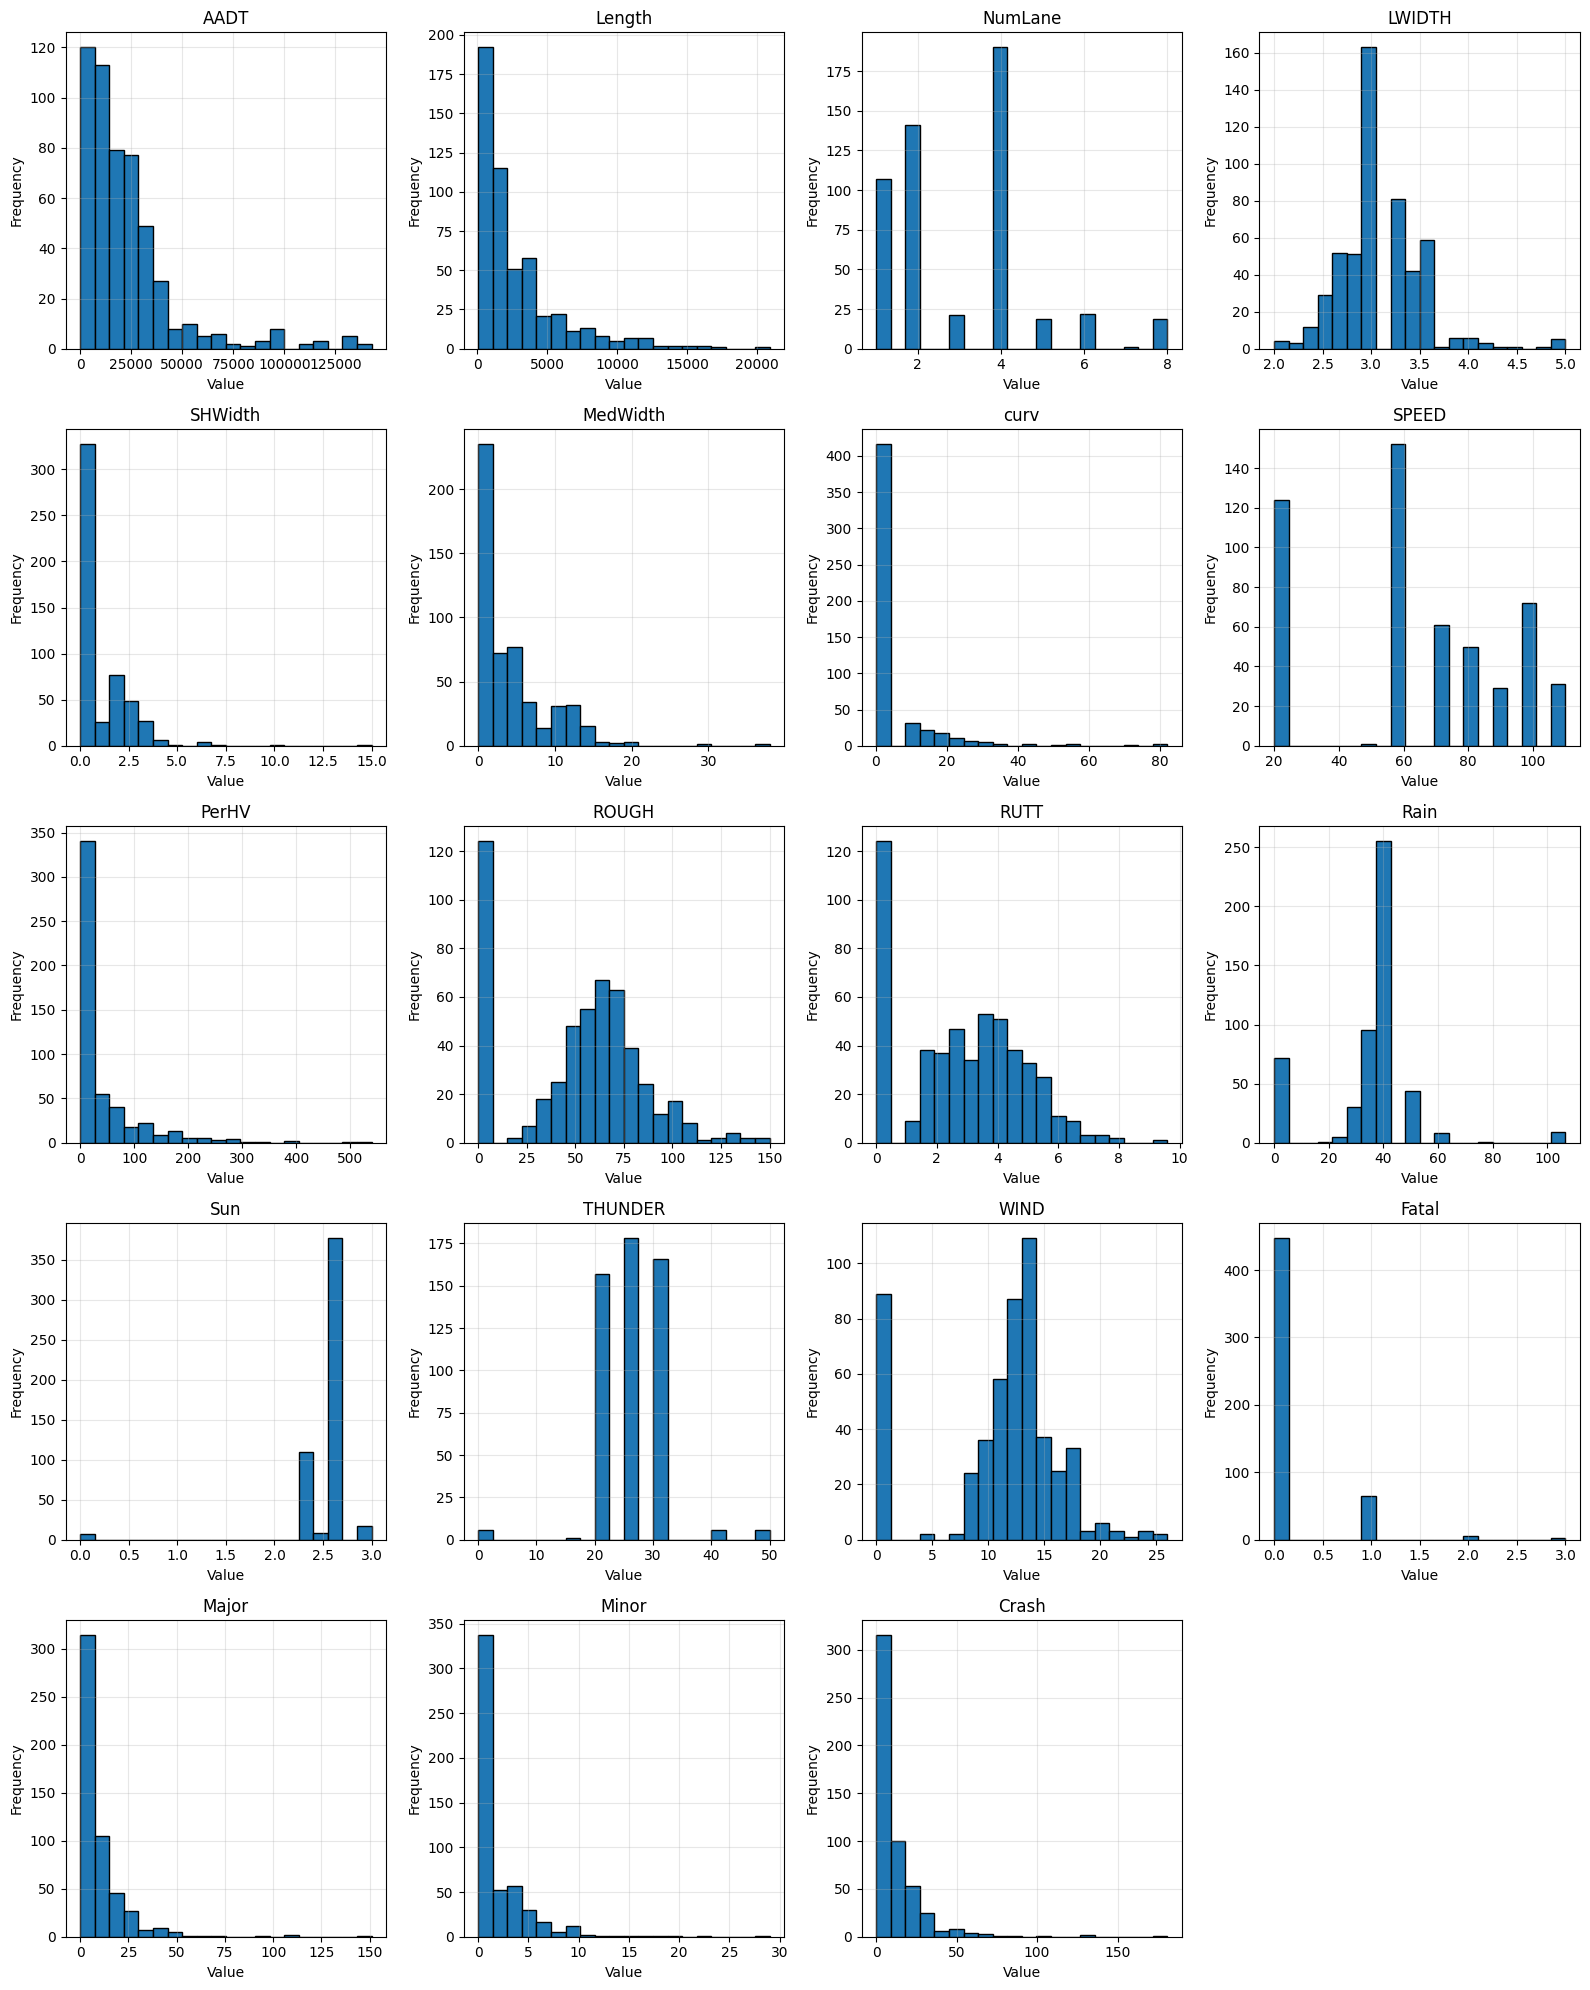

In [23]:
# Exclude ID and convert comma-formatted values to numeric
plot_df = df.drop(columns=["ID"]).apply(
    lambda col: pd.to_numeric(
        col.astype(str).str.replace(",", ".", regex=False),
        errors="coerce"
    )
)

# Exclude binary variables containing only 0 and 1
binary_cols = [
    col for col in plot_df.columns
    if set(plot_df[col].dropna().unique()).issubset({0, 1})
]

hist_df = plot_df.drop(columns=binary_cols).select_dtypes(include="number")

# Create histograms
n_cols = 4
n_rows = (len(hist_df.columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for ax, column in zip(axes, hist_df.columns):
    ax.hist(hist_df[column].dropna(), bins=20, edgecolor="black")
    ax.set_title(column)
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")
    ax.grid(alpha=0.3)

for ax in axes[len(hist_df.columns):]:
    ax.remove()

plt.tight_layout()
plt.show()

In [24]:
pearson_corr = plot_df.corr(method="pearson")

pearson_corr

,AADT,Length,NumLane,LWIDTH,FuncDum,Shoulder,SHType,SHWidth,SHMark,Median,...,ROUGH,RUTT,Rain,Sun,THUNDER,WIND,Fatal,Major,Minor,Crash
AADT,1.000000,-0.181483,0.388345,0.117791,-0.319384,0.102703,-0.011158,-0.026461,-0.023876,-0.309438,...,-0.202999,-0.134646,0.030012,0.000285,0.074099,0.052990,0.028478,0.137587,0.107451,0.134323
Length,-0.181483,1.000000,0.009811,-0.144508,0.429349,-0.302031,0.095902,0.226525,-0.025858,0.152412,...,0.309610,0.395780,-0.065078,0.026328,0.042114,-0.030744,0.264462,0.310405,0.253420,0.310129
NumLane,0.388345,0.009811,1.000000,0.037965,-0.139965,0.156343,-0.054456,-0.061262,-0.100119,-0.402512,...,0.315838,0.294523,0.002535,0.029071,0.066055,-0.030742,0.126271,0.324712,0.297886,0.326595
LWIDTH,0.117791,-0.144508,0.037965,1.000000,-0.143238,0.098027,-0.002185,-0.093363,0.110267,0.023893,...,-0.038950,-0.094701,0.048727,0.016225,0.195003,-0.151039,-0.108905,-0.027022,-0.027959,-0.030253
FuncDum,-0.319384,0.429349,-0.139965,-0.143238,1.000000,-0.275269,0.063407,0.207724,0.040632,0.243430,...,0.347940,0.345830,-0.166653,0.041085,-0.058160,-0.051958,0.077181,-0.222183,-0.219886,-0.222254
Shoulder,0.102703,-0.302031,0.156343,0.098027,-0.275269,1.000000,-0.256355,-0.733856,0.222639,-0.339726,...,-0.073778,-0.184870,0.095749,0.002122,-0.076679,-0.034989,-0.101549,0.057924,0.069842,0.058162
SHType,-0.011158,0.095902,-0.054456,-0.002185,0.063407,-0.256355,1.000000,0.165895,-0.085527,0.072176,...,0.007259,0.058718,-0.087192,0.034228,0.051181,0.008612,-0.031262,0.010186,-0.009299,0.005948
SHWidth,-0.026461,0.226525,-0.061262,-0.093363,0.207724,-0.733856,0.165895,1.000000,-0.144102,0.215789,...,0.050771,0.153192,-0.086127,-0.021638,0.048165,0.017605,0.124976,-0.062758,-0.069240,-0.061463
SHMark,-0.023876,-0.025858,-0.100119,0.110267,0.040632,0.222639,-0.085527,-0.144102,1.000000,0.052242,...,0.036604,-0.028252,-0.065345,-0.051307,0.029824,0.012708,-0.067681,-0.050939,-0.033882,-0.050103
Median,-0.309438,0.152412,-0.402512,0.023893,0.243430,-0.339726,0.072176,0.215789,0.052242,1.000000,...,0.100267,0.043566,-0.024771,-0.102664,-0.024053,-0.013180,-0.047284,-0.176787,-0.165354,-0.177847


In [25]:
# Pearson correlation matrix excluding SEAL and RUTT
pearson_corr = plot_df.drop(columns=["SEAL", "RUTT", "ROUGH"], errors="ignore").corr(
    method="pearson"
)

pearson_corr

,AADT,Length,NumLane,LWIDTH,FuncDum,Shoulder,SHType,SHWidth,SHMark,Median,...,PerHV,LOSDUM,Rain,Sun,THUNDER,WIND,Fatal,Major,Minor,Crash
AADT,1.000000,-0.181483,0.388345,0.117791,-0.319384,0.102703,-0.011158,-0.026461,-0.023876,-0.309438,...,-0.197921,0.245765,0.030012,0.000285,0.074099,0.052990,0.028478,0.137587,0.107451,0.134323
Length,-0.181483,1.000000,0.009811,-0.144508,0.429349,-0.302031,0.095902,0.226525,-0.025858,0.152412,...,0.276089,-0.067091,-0.065078,0.026328,0.042114,-0.030744,0.264462,0.310405,0.253420,0.310129
NumLane,0.388345,0.009811,1.000000,0.037965,-0.139965,0.156343,-0.054456,-0.061262,-0.100119,-0.402512,...,-0.125166,0.266962,0.002535,0.029071,0.066055,-0.030742,0.126271,0.324712,0.297886,0.326595
LWIDTH,0.117791,-0.144508,0.037965,1.000000,-0.143238,0.098027,-0.002185,-0.093363,0.110267,0.023893,...,-0.047926,0.103549,0.048727,0.016225,0.195003,-0.151039,-0.108905,-0.027022,-0.027959,-0.030253
FuncDum,-0.319384,0.429349,-0.139965,-0.143238,1.000000,-0.275269,0.063407,0.207724,0.040632,0.243430,...,0.318875,-0.047038,-0.166653,0.041085,-0.058160,-0.051958,0.077181,-0.222183,-0.219886,-0.222254
Shoulder,0.102703,-0.302031,0.156343,0.098027,-0.275269,1.000000,-0.256355,-0.733856,0.222639,-0.339726,...,-0.129470,-0.078629,0.095749,0.002122,-0.076679,-0.034989,-0.101549,0.057924,0.069842,0.058162
SHType,-0.011158,0.095902,-0.054456,-0.002185,0.063407,-0.256355,1.000000,0.165895,-0.085527,0.072176,...,0.110028,-0.005181,-0.087192,0.034228,0.051181,0.008612,-0.031262,0.010186,-0.009299,0.005948
SHWidth,-0.026461,0.226525,-0.061262,-0.093363,0.207724,-0.733856,0.165895,1.000000,-0.144102,0.215789,...,0.064268,0.109084,-0.086127,-0.021638,0.048165,0.017605,0.124976,-0.062758,-0.069240,-0.061463
SHMark,-0.023876,-0.025858,-0.100119,0.110267,0.040632,0.222639,-0.085527,-0.144102,1.000000,0.052242,...,-0.008312,-0.116120,-0.065345,-0.051307,0.029824,0.012708,-0.067681,-0.050939,-0.033882,-0.050103
Median,-0.309438,0.152412,-0.402512,0.023893,0.243430,-0.339726,0.072176,0.215789,0.052242,1.000000,...,0.183736,-0.076493,-0.024771,-0.102664,-0.024053,-0.013180,-0.047284,-0.176787,-0.165354,-0.177847


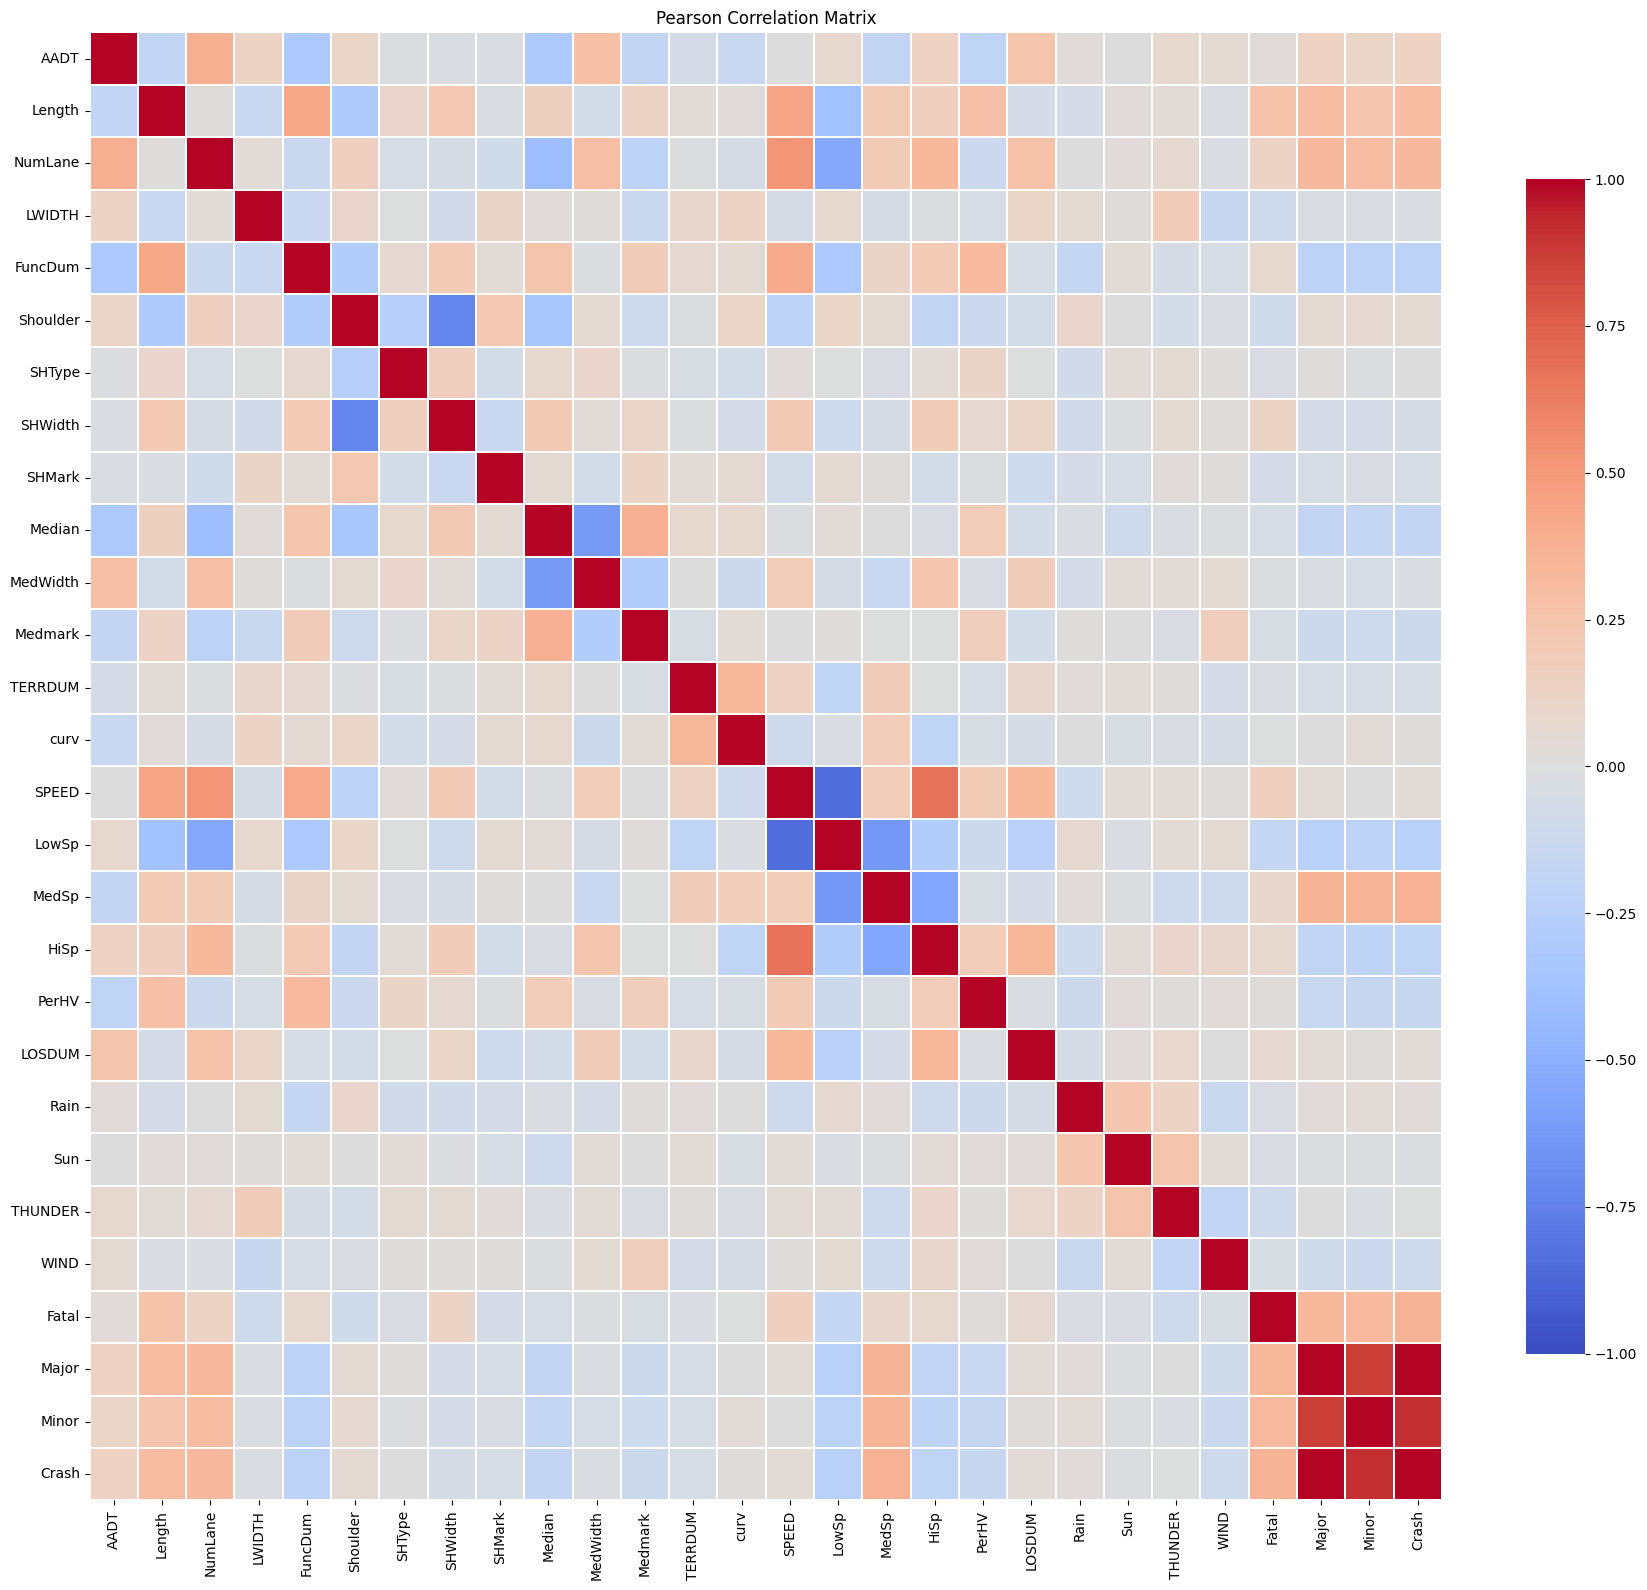

In [26]:
plt.figure(figsize=(18, 16))
sns.heatmap(
    pearson_corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    annot=False,
    linewidths=0.3,
    cbar_kws={"shrink": 0.8}
)
plt.title("Pearson Correlation Matrix")
plt.tight_layout()
plt.show()

# Safety Perfomance Functions

## Data Cleaning

In [ ]:
# Data Cleaning
# Some numerical variables contain commas as decimal separators
decimal_columns = [
    "PerHV",
    "ROUGH",
    "RUTT",
    "Rain",
    "Sun",
    "curv"
]

for col in decimal_columns:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(",", ".", regex=False),
        errors="coerce"
    )


# Convert road length from metres to kilometres
df["Length_km"] = df["Length"] / 1000


# Log-transform AADT
df["log_AADT"] = np.log(df["AADT"])

# Setup Variables
# Dependent variable
y = df["Crash"]

# Independent Variables
# EDIT ONLY THIS LIST TO ADD OR REMOVE VARIABLES
# RUTT, ROUGH and SEAL taken out due to correlation
predictors = [
    "log_AADT",
    "NumLane",
    "LWIDTH",
    "FuncDum",
    "Shoulder",
    "SHWidth",
    "SHMark",
    "Median",
    "MedWidth",
    "Medmark",
    "TERRDUM",
    "curv",
    "SPEED",
    "PerHV",
    "LOSDUM",
    "Rain",
    "Sun",
    "THUNDER",
    "WIND"
]
X = df[predictors]

# Add regression intercept
X = sm.add_constant(X)

model_data = pd.concat(
    [y, X, df["Length_km"]],
    axis=1
).dropna()

y_model = model_data["Crash"]

X_model = model_data[
    ["const"] + predictors
]

length_model = model_data["Length_km"]


## Negative Binomial Model

In [28]:
# Negative Binomial Regression Model
nb_model = NegativeBinomial(
    endog=y_model,
    exog=X_model,

    # Length is treated as exposure.
    # statsmodels automatically uses log(Length_km)
    exposure=length_model,

    # NB2: Var(Y) = mu + alpha * mu^2
    loglike_method="nb2"
)

nb_results = nb_model.fit(
    maxiter=500,
    disp=False
)
print("\n==============================")
print("NEGATIVE BINOMIAL MODEL")
print("==============================\n")

# Extract the dispersion parameter (alpha)
alpha = nb_results.params["alpha"]

print("\nEstimated dispersion parameter (alpha):")
print(alpha)

# Print the model results summary
print(nb_results.summary())


# Analyse impact of each variable on the expected number of crashes
coefficients = nb_results.params.drop("alpha")

IRR = np.exp(coefficients)

results_table = pd.DataFrame({
    "Coefficient": coefficients,
    "IRR": IRR,
    "P-value": nb_results.pvalues.drop("alpha")
})

print("\n==============================")
print("COEFFICIENTS AND IRRs")
print("==============================\n")

print(results_table)


# Predict Crashes
df.loc[model_data.index, "Predicted_Crashes_NB"] = nb_results.predict(
    X_model,
    exposure=length_model
)

print("\nFirst predicted values:")
print(
    df[
        ["ID", "Crash", "Predicted_Crashes_NB"]
    ].head(10)
)


NEGATIVE BINOMIAL MODEL


Estimated dispersion parameter (alpha):
0.42527946462568506
                     NegativeBinomial Regression Results                      
Dep. Variable:                  Crash   No. Observations:                  520
Model:               NegativeBinomial   Df Residuals:                      500
Method:                           MLE   Df Model:                           19
Date:                Wed, 16 Sep 2026   Pseudo R-squ.:                  0.1118
Time:                        14:43:02   Log-Likelihood:                -1557.7
converged:                       True   LL-Null:                       -1753.8
Covariance Type:            nonrobust   LLR p-value:                 1.756e-71
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.5098      0.655     -0.778      0.436      -1.794       0.774
log_AADT       0.3100      0.048      6.487 

## Poisson Model

In [29]:
# Poisson Regression Model

poisson_model = Poisson(
    endog=y_model,
    exog=X_model,
    # Length is treated as exposure (statsmodels auto-logs this)
    exposure=length_model
)

poisson_results = poisson_model.fit(
    maxiter=500,
    disp=False
)

print("\n==============================")
print("POISSON MODEL RESULTS")
print("==============================\n")

# Print the model summary
print(poisson_results.summary())


# Analyse impact of each variable on the expected number of crashes

coefficients = poisson_results.params
IRR = np.exp(coefficients)

results_table = pd.DataFrame({
    "Coefficient": coefficients,
    "IRR": IRR,
    "P-value": poisson_results.pvalues
})

print("\n==============================")
print("COEFFICIENTS AND IRRs (POISSON)")
print("==============================\n")

print(results_table)


# Predict Crashes

df.loc[model_data.index, "Predicted_Crashes_Poisson"] = poisson_results.predict(
    X_model,
    exposure=length_model
)

print("\nPredicted crashes (Poisson):")
print(
    df[
        ["ID", "Crash", "Predicted_Crashes_Poisson"]
    ].head(10)
)


POISSON MODEL RESULTS

                          Poisson Regression Results                          
Dep. Variable:                  Crash   No. Observations:                  520
Model:                        Poisson   Df Residuals:                      500
Method:                           MLE   Df Model:                           19
Date:                Wed, 16 Sep 2026   Pseudo R-squ.:                  0.5377
Time:                        14:43:02   Log-Likelihood:                -2196.7
converged:                       True   LL-Null:                       -4751.8
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0155      0.275     -0.056      0.955      -0.554       0.523
log_AADT       0.2672      0.022     12.191      0.000       0.224       0.310
NumLane        0.1409      0

# Empirical Bayes Method

In [ ]:
# Define the testroad characteristics --> same variables as used for training (binomial filtered out, AADT log-transformed, length in km)
# RUTT, ROUGH and SEAL taken out due to correlation

test_road = pd.DataFrame(
    [
        {
            "log_AADT": np.log(41000),
            "NumLane": 3,
            "LWIDTH": 3.5,
            "FuncDum": 0,
            "Shoulder": 1,
            "SHWidth": 0,
            "SHMark": 0,
            "Median": 0,
            "MedWidth": 13,
            "Medmark": 0,
            "TERRDUM": 0,
            "curv": 0.6137,
           #"SEAL": 1,
            "SPEED": 80,
            "PerHV": 6.5,
            "LOSDUM": 0,
            #"ROUGH": 70,
            #"RUTT": 5,
            "Rain": 30,
            "Sun": 2,
            "THUNDER": 20,
            "WIND": 15,
        }
    ]
)

# Add a constant to the test road data for the intercept
test_road_with_const = sm.add_constant(test_road, has_constant="add")

In [31]:
print(nb_results.params)

const      -0.509850
log_AADT    0.309995
NumLane     0.189362
LWIDTH      0.049654
FuncDum    -0.631191
Shoulder    0.128284
SHWidth    -0.056542
SHMark     -0.008594
Median      0.124150
MedWidth   -0.020585
Medmark    -0.156707
TERRDUM     0.116774
curv        0.006290
SPEED      -0.017746
PerHV      -0.001898
LOSDUM      0.255779
Rain       -0.003054
Sun         0.165536
THUNDER    -0.017225
WIND       -0.014786
alpha       0.425279
dtype: float64


In [32]:
print(test_road_with_const)

   const   log_AADT  NumLane  LWIDTH  FuncDum  Shoulder  SHWidth  SHMark  \
0    1.0  10.621327        3     3.5        0         1        0       0   

   Median  MedWidth  Medmark  TERRDUM    curv  SPEED  PerHV  LOSDUM  Rain  \
0       0        13        0        0  0.6137     80    6.5       0    30   

   Sun  THUNDER  WIND  
0    2       20    15  


In [33]:
# Apply the SPF from the NB model to the test road

pred_annual = nb_results.predict(test_road_with_const)[0]
n_pred_2yr = pred_annual * 2

print(f"2-Year Predicted Crashes: {n_pred_2yr:.2f}")

2-Year Predicted Crashes: 10.21


In [34]:
# Weight determination based on the predicted number of crashes and the dispersion parameter

# Observations and Dispersion Parameter
alpha = 0.348521
obs_fatal, obs_major, obs_minor = 5, 35, 10
obs_total_2yr = obs_fatal + obs_major + obs_minor

# Weight calculation
weight = 1 / (1 + alpha * n_pred_2yr)
print (f"Weight for the test road: {weight:.4f}")

Weight for the test road: 0.2194


In [35]:
# Expected total crashes over 2 years
n_expected_2yr = (weight * n_pred_2yr) + ((1 - weight) * obs_total_2yr)
print(f"Expected total crashes over 2 years: {n_expected_2yr:.2f}")

Expected total crashes over 2 years: 41.27


In [36]:
# Factor in severoity distribution based on observed crash data
n_expected_2yr = n_expected_2yr
exp_fatal = n_expected_2yr * (obs_fatal / obs_total_2yr)
exp_major = n_expected_2yr * (obs_major / obs_total_2yr)
exp_minor = n_expected_2yr * (obs_minor / obs_total_2yr)

In [37]:
# Print the summary of predicted crashes based on the EBM
print(f"2-Year SPF Predicted Crashes: {n_pred_2yr:.2f}")
print(f"EB Weight Factor (w): {weight:.4f}")
print(f"2-Year Expected Total Crashes: {n_expected_2yr:.2f}")
print(f"  - Fatal: {exp_fatal:.2f} crashes/year")
print(f"  - Major: {exp_major:.2f} crashes/year")
print(f"  - Minor: {exp_minor:.2f} crashes/year")


2-Year SPF Predicted Crashes: 10.21
EB Weight Factor (w): 0.2194
2-Year Expected Total Crashes: 41.27
  - Fatal: 4.13 crashes/year
  - Major: 28.89 crashes/year
  - Minor: 8.25 crashes/year
